In [32]:
from pathlib import Path

import gffutils
import numpy as np
import polars as pl
from safetensors.torch import load_file
import seaborn as sns
from tqdm import tqdm
from umap import UMAP

import torch

## Data

In [2]:
db = gffutils.FeatureDB("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/gencode.v48.chr21.db")

## Utils

In [4]:
def get_codon_position_arrays(db, gene_type=None):
    """
    Extract first, second, and third codon positions from a gffutils.FeatureDB object.

    Parameters:
    - db (gffutils.FeatureDB): A database created from a GFF3 file with CDS annotations.

    Returns:
    - Tuple of numpy.ndarrays: (pos1, pos2, pos3), containing genomic coordinates.
    """
    pos1 = []
    pos2 = []
    pos3 = []

    for tx in db.features_of_type('transcript', order_by='start'):
        if gene_type and gene_type not in tx["gene_type"]:
            continue

        cds_list = list(db.children(tx, featuretype='CDS', order_by='start'))

        if not cds_list:
            continue

        strand = cds_list[0].strand

        # Build list of genomic positions based on CDS exons
        cds_coords = []

        if strand == '+':
            for cds in cds_list:
                phase = int(cds.frame) if cds.frame != '.' else 0
                coords = list(range(cds.start + phase, cds.end + 1))
                cds_coords.extend(coords)
        else:
            for cds in reversed(cds_list):
                phase = int(cds.frame) if cds.frame != '.' else 0
                coords = list(range(cds.start, cds.end - phase + 1))
                cds_coords.extend(coords[::-1])  # reverse for negative strand

        # Assign codon positions
        for i, coord in enumerate(cds_coords):
            if i % 3 == 0:
                pos1.append(coord)
            elif i % 3 == 1:
                pos2.append(coord)
            else:
                pos3.append(coord)

    return np.array(pos1), np.array(pos2), np.array(pos3)


In [13]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
size = 2**20
stride = size - 8192
chr_size = 46709983

def get_feature_embeddings(idx, *args, **kwargs):
    sample_size = kwargs.get("sample_size", 100)
    seed = kwargs.get("seed", 42)

    rng = np.random.default_rng()
    sample = np.sort(rng.choice(idx, size=sample_size))

    all_embeddings = []

    for start in tqdm(range(0,chr_size,stride)):
        offset = start + 8192
        end = start + size
        filename = f"ch38_chr21_{start}_{end}_embeddings.safetensors"

        try:
            chunk_embeddings = load_file(basepath / filename)["embeddings"]
        except FileNotFoundError:
            print(f"{filename} not found")
            continue

        for index in sample:
            if index >= end:
                break
            if index > offset:
                offset_idx = index - offset
                index_embeddings = chunk_embeddings[offset_idx,:].unsqueeze(0)
                all_embeddings.append(index_embeddings)

        del chunk_embeddings

    return torch.cat(all_embeddings, 0)

In [20]:
def tensor_to_df(tensor, label):
    return pl.DataFrame({"embedding": tensor.numpy(), "label": [label] * tensor.shape[0]})

In [21]:
def embed_dfs(dfs, reducer):
    df_all = pl.concat(dfs).with_columns(pl.col("embedding").arr.to_struct()).unnest("embedding")
    umap_embedding = reducer.fit_transform(df_all.select(pl.exclude("label")))
    df_all_umap = pl.DataFrame(umap_embedding).hstack(df_all.select("label"))
    return df_all_umap

In [36]:
def plot_umap(df_umap):
    ax = sns.scatterplot(df_umap, x="column_0", y="column_1", hue="label", s=8)

    ax.set_title("Codon positions in embedding space")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="Position")

    return ax

## Analysis

In [8]:
pos1, pos2, pos3 = get_codon_position_arrays(db, gene_type="protein_coding")

In [9]:
pos1

array([10538724, 10538727, 10538730, ..., 46636982, 46636985, 46636988])

In [18]:
emb1 = get_feature_embeddings(pos1, sample_size=1000)
emb2 = get_feature_embeddings(pos2, sample_size=1000)
emb3 = get_feature_embeddings(pos3, sample_size=1000)

100%|██████████| 45/45 [00:00<00:00, 1464.88it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


100%|██████████| 45/45 [00:00<00:00, 2030.57it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


100%|██████████| 45/45 [00:00<00:00, 2039.83it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [26]:
df_pos1 = tensor_to_df(emb1, "Position 1")
df_pos2 = tensor_to_df(emb2, "Position 2")
df_pos3 = tensor_to_df(emb3, "Position 3")

In [29]:
reducer = UMAP(min_dist=0.4, metric="cosine", random_state=42)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'Codon positions in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

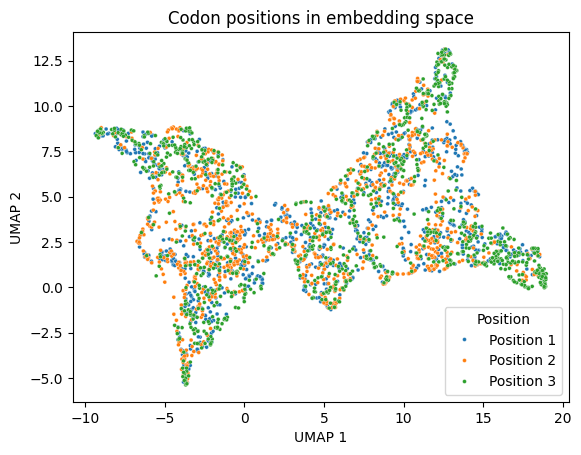

In [37]:
umap_all = embed_dfs((df_pos1, df_pos2, df_pos3), reducer)
plot_umap(umap_all)